# Bank Marketing

## 1. Enlace al conjunto de datos original

Grupo:

Bohl Santiago      santiagobohl@gmail.com

González Zelante Facundo facu.gzelante@gmail.com

Ojeda Joaquin Ezequiel  joaquinojeda7777@gmail.com

Sanchez Rios Santiago Tomas  santitomas2711@gmail.com





Dataset: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing?resource=download

## 2. Descripcion


Fuente original: UCI Machine Learning Repository
Dataset: Bank Marketing Data Set



Este conjunto de datos proviene de una campaña de marketing realizada por una entidad bancaria portuguesa. El objetivo de dicha campaña era promocionar un producto financiero específico: depósitos a plazo (term deposits).

Los datos fueron obtenidos a partir de llamadas telefónicas realizadas por teleoperadores a distintos clientes, y recogen información tanto del perfil socioeconómico del cliente como del contexto de la campaña (fecha, tipo de contacto, resultado de campañas anteriores, indices socioeconómicos, etc.).

## 3. EDA


Cantidad de registros ( luego de limpieza): 39.855 observaciones.

Cantidad de variables: 21 variables (entre características del cliente, del contacto y del entorno económico).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from math import ceil
import seaborn as sns
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages


In [ ]:
df = pd.read_csv("data/bank-additional-full.csv", sep=";")

Estas son las columnas del dataset

- Variables categoricas:
> job - marital - education - default - housing - loan - contact - month - day_of_week - poutcome - pdays
- Variables numericas continuas:
> age - duration - campaign - previous
- Luego hay variables numericas no continuas (tienen poca variabilidad):
> emp.var.rate - cons.price.idx - cons.conf.idx - euribor3m - nr.employed
- Y la variable target "y"

In [ ]:
print("Variables del Dataset")
print(df.info())


Variables del Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Los valores na de todas las columnas estan codificados como "unknown". Por eso no existen valores nulos en todo el dataset

Sacamos los valores Unknown de las variables Job y Housing, sacamos los valores iliterate (sin estudios) de la variable edication. Reemplazamos los valores Unknown por los mas comunes en cada caso de las variables marital (Estado civil) y loan (prestamos). Porque en estas variables la cantidad de unknown son muy pequeñas y consideramos que no afectaria eliminarlas. Y en el caso de marital y loan son variables muy desbalanceadas.

In [ ]:
for column in ["job", "housing"]:
    df = df[df[column] != "unknown"]

In [ ]:
df = df[df["education"] != "illiterate"]

In [ ]:
most_common = df['marital'].mode()[0]
df['marital'] = df['marital'].replace('unknown', most_common)

most_common = df['loan'].mode()[0]
df['loan'] = df['loan'].replace('unknown', most_common)

In [ ]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 39855
Columnas: 21


Se muestran los graficos de distribucion de valores para cada variable

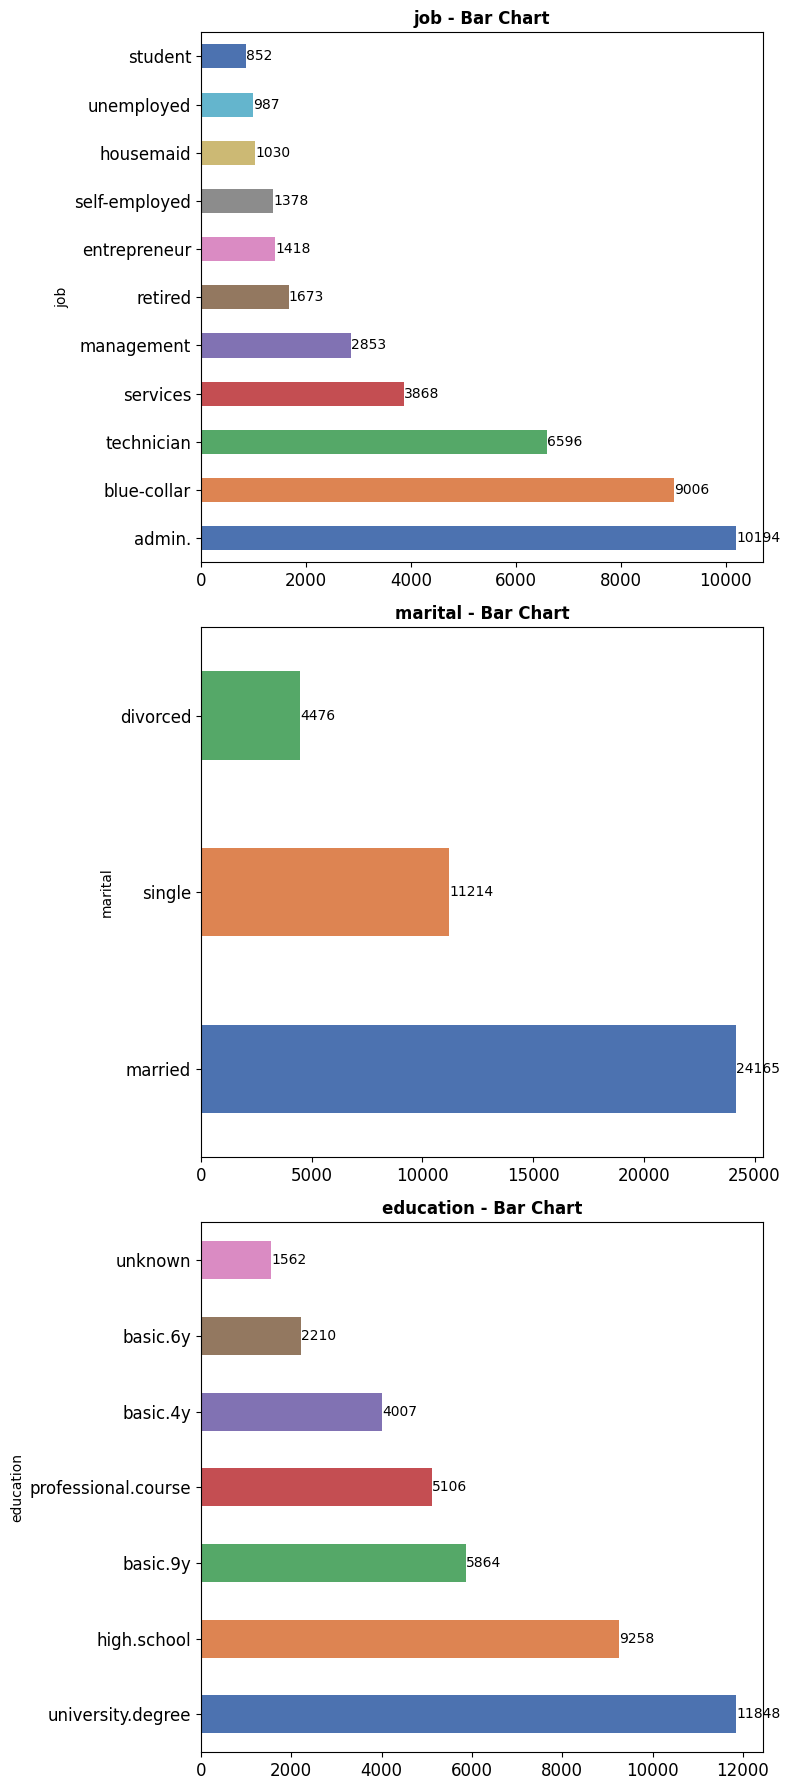

In [ ]:

def graficos_eda_categorico(cat):

    categorical_vars = cat.select_dtypes(include=["object"]).columns.tolist()
    num_vars = len(categorical_vars)

    filas = ceil(num_vars)

    f, ax = plt.subplots(nrows=filas, ncols=1, figsize=(8, filas * 6))


    if num_vars == 1:
        ax = [ax]


    for cada, variable in enumerate(categorical_vars):
        value_counts = cat[variable].value_counts(dropna=False)
        unique_values = value_counts.index.tolist()
        num_unique = len(unique_values)
        color_palette = sns.color_palette("deep", n_colors=num_unique)


        bar = value_counts.plot.barh(ax=ax[cada], color=color_palette)
        ax[cada].set_title(f"{variable} - Bar Chart", fontsize=12, fontweight="bold")
        ax[cada].tick_params(labelsize=12)

        for bar in bar.patches:
            ax[cada].text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f"{int(bar.get_width())}",
                          va="center", ha="left", fontsize=10)

    plt.tight_layout()
    plt.show()

graficos_eda_categorico(df[["job","marital", "education"]])
#llamamos la funcion por partes para poder que se exporte correctamente


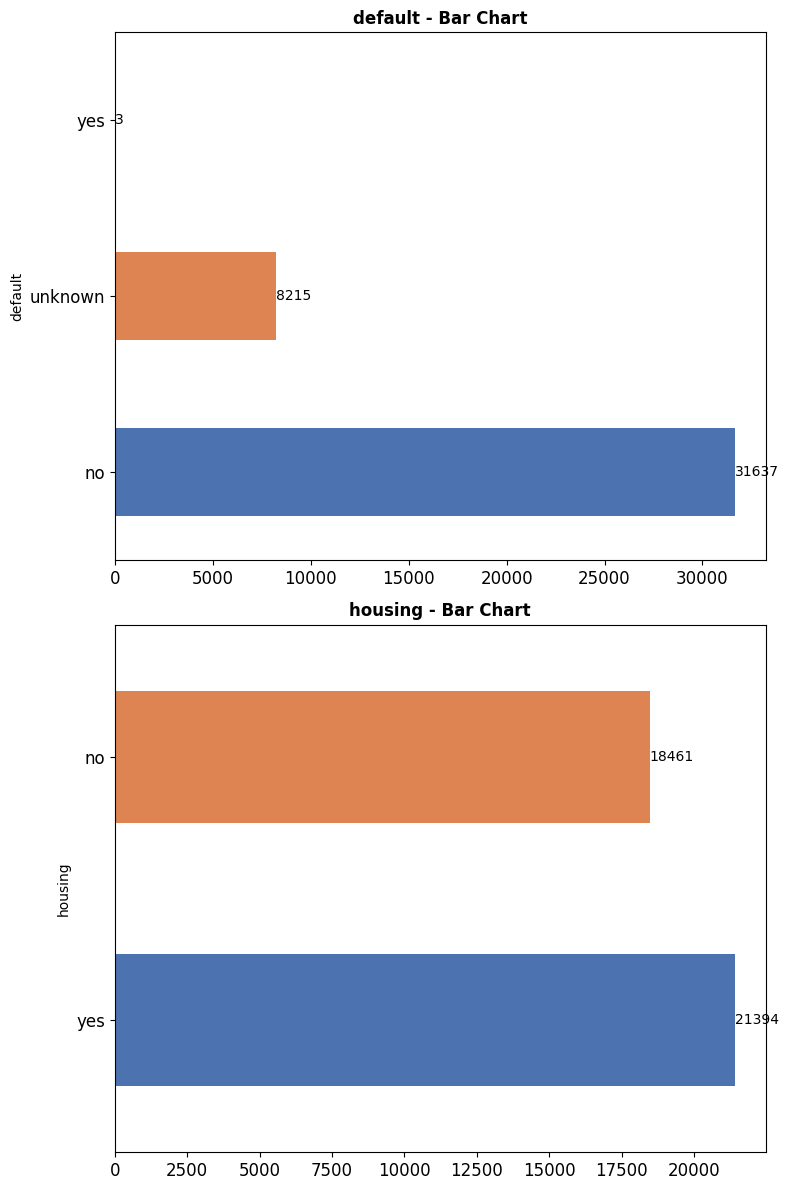

In [ ]:
graficos_eda_categorico(df[[ "default", "housing"]])

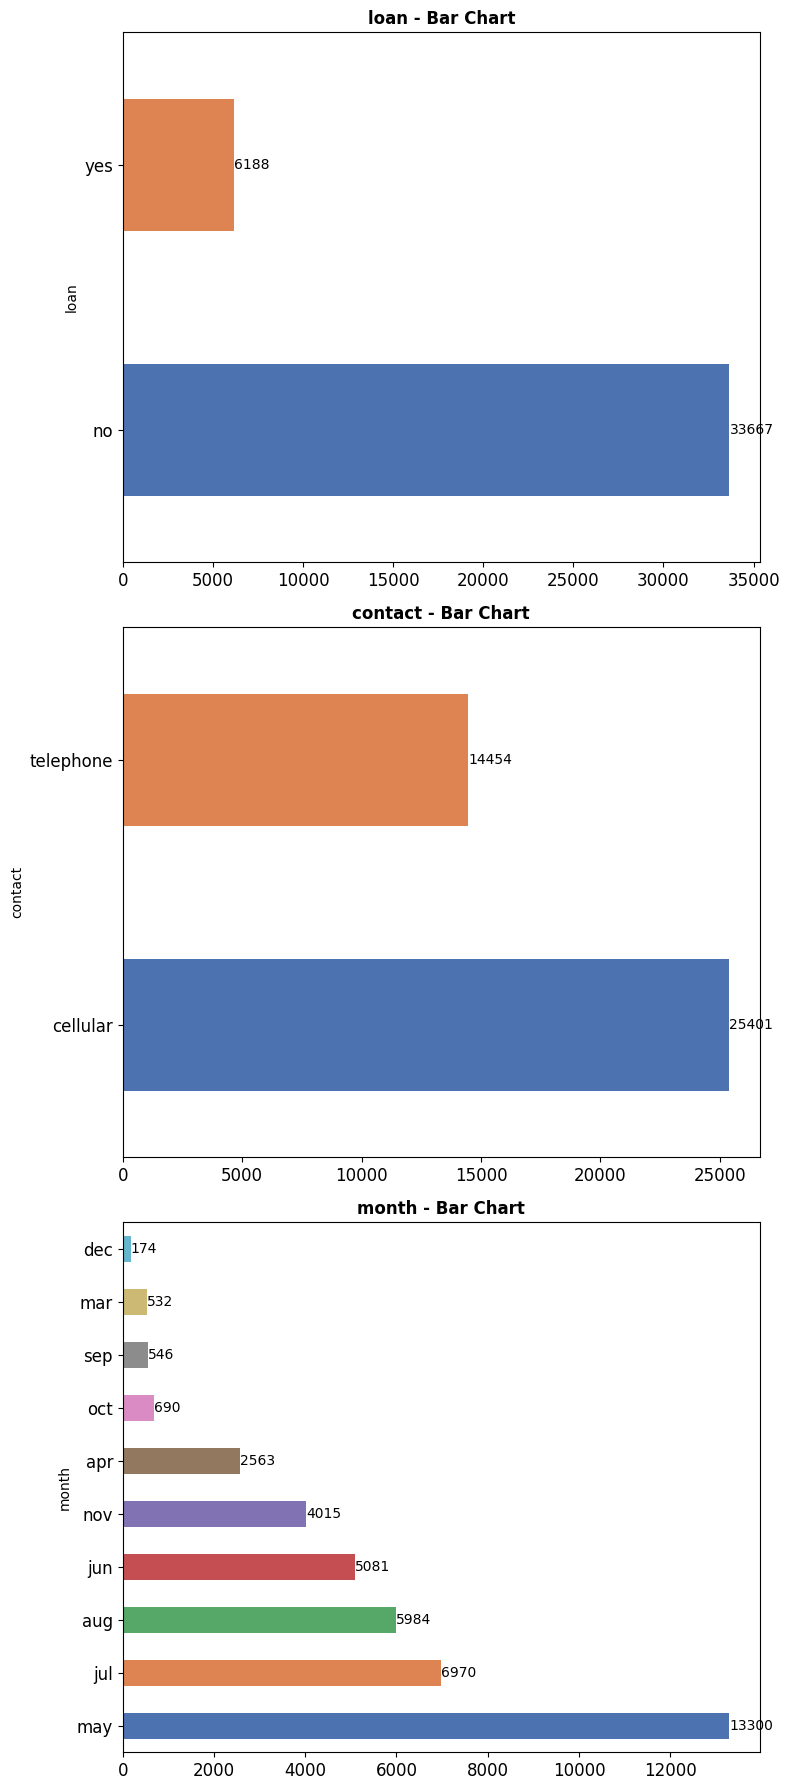

In [ ]:
graficos_eda_categorico(df[[ "loan", "contact", "month"]])

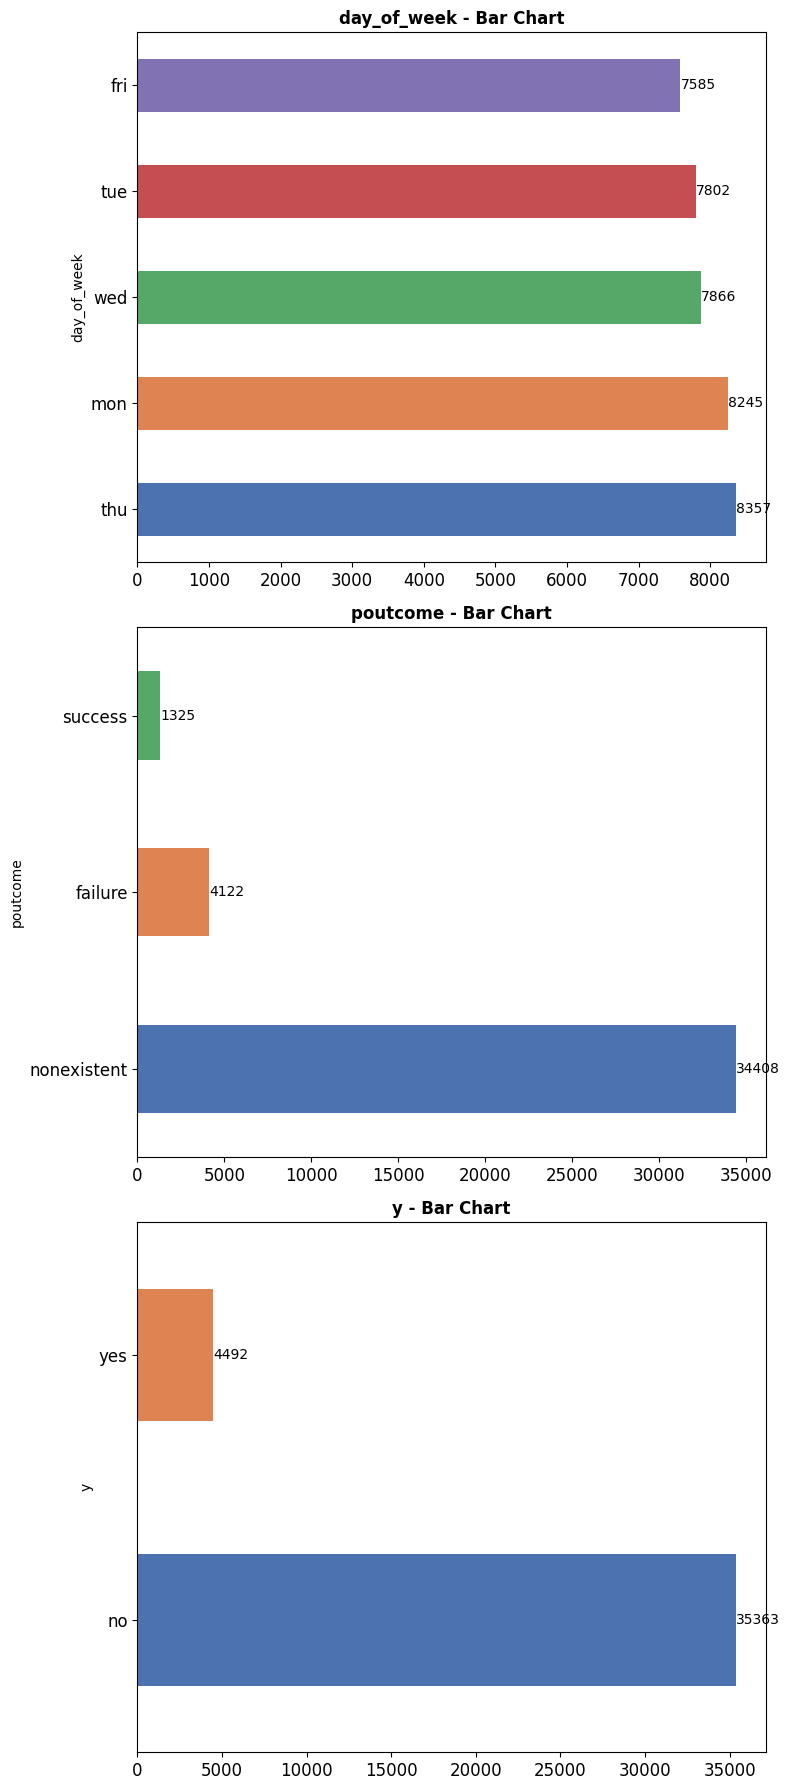

In [ ]:
graficos_eda_categorico(df[["day_of_week", "poutcome", "y"]])

In [ ]:
def metrica_continuo(num):
    metricas = num.describe().T
    #metricas["median"] = num.median()
    metricas = metricas.iloc[:,[0,1,2,3,4,5,6,7]] # mediana al lado de la media
    return metricas

Ahoea vemos la distribucion de las variables numericas

In [ ]:
metrica_continuo(df.select_dtypes("number"))

,count,mean,std,min,25%,50%,75%,max
age,39855.0,39.976590,10.402027,17.000,32.000,38.000,47.000,98.000
duration,39855.0,258.629708,259.414627,0.000,102.000,180.000,320.000,4918.000
campaign,39855.0,2.567081,2.765742,1.000,1.000,2.000,3.000,43.000
pdays,39855.0,962.624940,186.540641,0.000,999.000,999.000,999.000,999.000
previous,39855.0,0.172826,0.494248,0.000,0.000,0.000,0.000,7.000
emp.var.rate,39855.0,0.079049,1.569860,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,39855.0,93.573134,0.577972,92.201,93.075,93.444,93.994,94.767
cons.conf.idx,39855.0,-40.521744,4.629119,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,39855.0,3.617993,1.734483,0.634,1.344,4.857,4.961,5.045
nr.employed,39855.0,5167.003262,72.209460,4963.600,5099.100,5191.000,5228.100,5228.100


## 4. Exposición del problema

El objetivo principal es predecir si un cliente realizará una inversión (variable "y"), utilizando los datos disponibles de campañas de marketing previas. La variable "y" indica si el cliente aceptó ("yes") o no ("no") una oferta de suscripción a un producto financiero (depósito a plazo).

Se busca entender qué factores influyen más en la decisión del cliente y, en base a eso, generar estrategias para incrementar la tasa de compra.

Este es un problema de clasificación binaria, ya que el target (y) toma solo dos valores:

    "yes": el cliente invirtió.

    "no": el cliente no invirtió.

📏 Métricas para evaluar el modelo

Dado que los datos estan desbalanceados en el target  (probablemente más "no" que "yes"), no alcanza con usar accuracy como única métrica. Las métricas sugeridas son:

    Accuracy: proporción total de aciertos.

    Precision: qué porcentaje de los que el modelo predijo como "yes" efectivamente lo son.

    Recall (sensibilidad): qué porcentaje de los que realmente dijeron "yes" fueron correctamente identificados.

    F1-score: equilibrio entre precision y recall.

    ROC-AUC: mide la capacidad del modelo de separar clases correctamente.

## 5. Eleccion de atributos predictivos
Dado el target propuesto, elegir dos atributos (sólo dos) que crean que tengan un buen poder predictivo con respecto a ese target. Explicar por quécreen que es el caso y proveer uno o dos gráficos (no más) que muestren sies o no así. (No se preocupen si aún no da como esperan).

Analizamos varias variables categoricas.
E intentamos ver cual contenia una mayor proporcion de "yes".
Estas son las que consiguieron mayor diferencia.

El puesto de trabajo que el cliente tiene puede estar afectado con la variable edad que analizamos antes.
Los jovenes y los de mayor edad tienen una mayor proporcion de "yes". Similar a lo que estamos viendo.

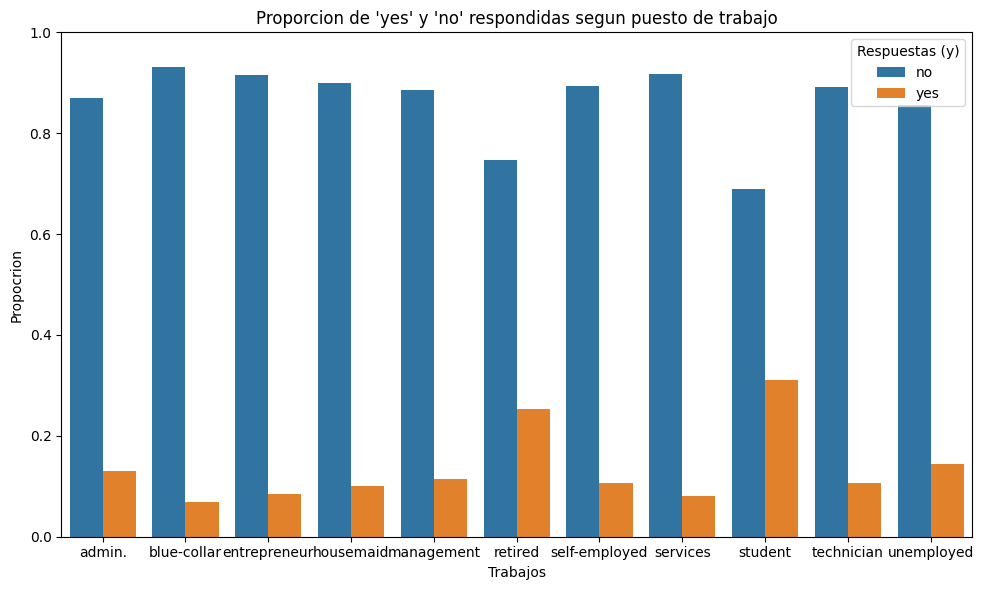

In [ ]:
counts = df.groupby(["job", "y"]).size().reset_index(name="count")

counts["proportion"] = counts.groupby("job")["count"].transform(lambda x: x / x.sum())

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=counts, x="job", y="proportion", hue="y")
plt.title("Proporcion de 'yes' y 'no' respondidas segun puesto de trabajo")
plt.ylabel("Propocrion")
plt.xlabel("Trabajos")
plt.ylim(0, 1)
plt.legend(title="Respuestas (y)")
plt.tight_layout()
plt.show()

Este grafico muestra como la variable age tiene una mayor densidad de datos alrededor de las edades de 20 años a 60.

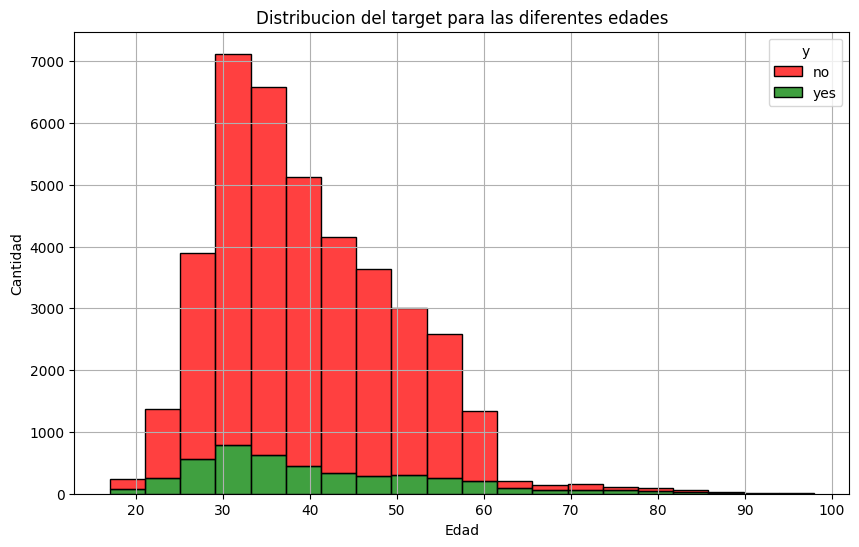

In [ ]:

# Ensure age is numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df.dropna(subset=['age'])

# Plot histogram, colored by 'y'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='y', multiple='stack', palette={'yes': 'green', 'no': 'red'}, bins=20)
plt.title("Distribucion del target para las diferentes edades")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.grid(True)
plt.show()

Este grafico nos muestra con mayor claridad como la edad puede afectar a la respuesta del cliente.
Si bien con el grafico podemos ver como las edades de 20 y las superiores a 60 tienen una mayor chance de decir "si", estos datos pueden haber sido distorcionados por la poca cantidad de datos que estas tienen.

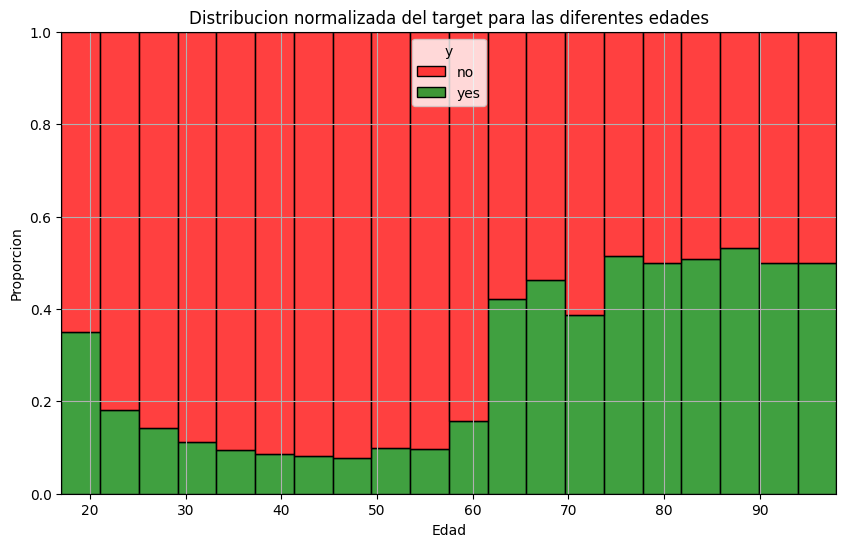

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='age',
    hue='y',
    multiple='fill',
    stat='probability',
    palette={'yes': 'green', 'no': 'red'},
    bins=20
)
plt.title("Distribucion normalizada del target para las diferentes edades")
plt.xlabel("Edad")
plt.ylabel("Proporcion")
plt.grid(True)
plt.show()
